**END-TO-END AI FOR SCIENCE · CRASH SIMULATION TRACK**

# Notebook2: Training and Time-Integration Comparison

**Executed PhysicsNeMo case study · native VTP data.**

This notebook runs one complete classroom workflow: a fresh two-epoch, position-only one-shot
training run, validation after each epoch, and inference from the new epoch-2 checkpoint. The
short run demonstrates how the PhysicsNeMo recipe works; it is not an accuracy benchmark.

The final sections contain embedded figures from a separate, completed three-method study. Those
figures compare one-shot, time-conditioned, and autoregressive models trained with the full crash
recipe. They are reference evidence and are not regenerated by this notebook.

> **Target scope.** The executable demonstration and the reference comparison predict position
> only, `[N, 50, 3]`. Effective plastic strain and von-Mises stress are present in the source VTPs
> but are not predicted by these checkpoints.

## Workflow components

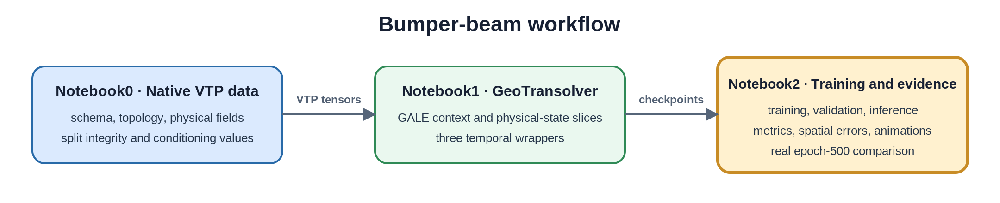

Notebook0 prepares the VTP data, Notebook1 defines the GeoTransolver architecture, and Notebook2
executes training, validation, inference, and temporal-strategy comparison.


## 1. Reference workflow and notebook scope

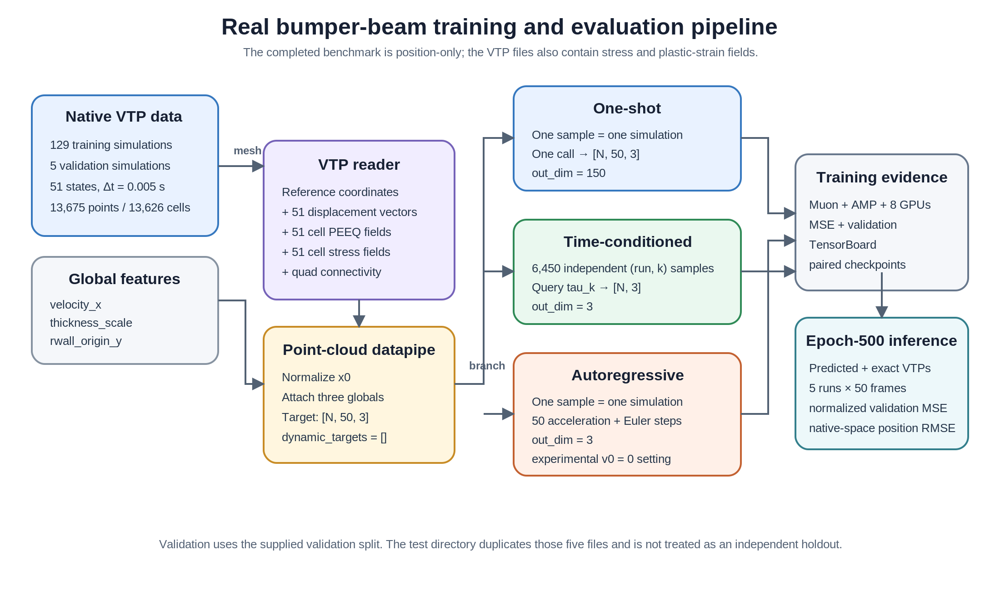

The diagram summarizes the full three-method study. The executable cells in this notebook use
the same VTP reader, point-cloud datapipe, trainer, validation loop, checkpoint format, and
inference exporter for a two-epoch one-shot run only.

The supplied `test/` files are byte-identical to the five `validation/` files; inference here is
therefore validation inference rather than an independent test result.

## 2. Reproducible environment and paths

The recipe and dataset are discovered from the current working directory or selected with
`CRASH_PROJECT_ROOT`, `PHYSICSNEMO_CRASH_RECIPE`, and `BUMPER_BEAM_DATA_ROOT`. Live output defaults
to `notebook2_output/` and can be changed with `NOTEBOOK2_DEMO_DIR`. Historical job directories are
not part of the notebook contract.


In [1]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
from IPython.display import display
import json, os, re, sys, warnings
warnings.filterwarnings("ignore", message="IProgress not found.*")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyvista as pv
import torch
import physicsnemo

def locate_recipe():
    candidates = []
    configured_recipe = os.environ.get("PHYSICSNEMO_CRASH_RECIPE")
    configured_root = os.environ.get("CRASH_PROJECT_ROOT")
    if configured_recipe:
        candidates.append(Path(configured_recipe).expanduser())
    if configured_root:
        candidates.append(
            Path(configured_root).expanduser()
            / "physicsnemo/examples/structural_mechanics/crash"
        )
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidates.append(base / "physicsnemo/examples/structural_mechanics/crash")
    for candidate in candidates:
        if (candidate / "train.py").is_file() and (candidate / "vtp_reader.py").is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        "PhysicsNeMo crash recipe not found. Set PHYSICSNEMO_CRASH_RECIPE or CRASH_PROJECT_ROOT."
    )

def locate_dataset():
    candidates = []
    configured = os.environ.get("BUMPER_BEAM_DATA_ROOT")
    if configured:
        candidates.append(Path(configured).expanduser())
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidates.extend([base / "datasets/bumper_beam", base / "data/bumper_beam"])
    candidates.append(Path("/workspace/datasets/bumper_beam"))
    for candidate in candidates:
        if (candidate / "train").is_dir() and (candidate / "validation").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Bumper-beam dataset not found. Set BUMPER_BEAM_DATA_ROOT before starting Jupyter."
    )


RECIPE_DIR = locate_recipe()
DATA_ROOT = locate_dataset()
DEMO_RUN = Path(os.environ.get(
    "NOTEBOOK2_DEMO_DIR", str(Path.cwd() / "notebook2_output")
)).expanduser().resolve()

for required in [RECIPE_DIR / "train.py", RECIPE_DIR / "inference.py",
                 DATA_ROOT / "global_features.json"]:
    assert required.exists(), required

def package_version(name):
    try:
        return version(name)
    except PackageNotFoundError:
        return "not installed"

print(f"Python      : {sys.version.split()[0]}")
print(f"PhysicsNeMo : {getattr(physicsnemo, '__version__', package_version('nvidia-physicsnemo'))}")
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA visible: {torch.cuda.device_count()} device(s)")
print("Recipe      : train.py and inference.py found")
print("Dataset     : global_features.json found")


Python      : 3.12.3
PhysicsNeMo : 2.2.0
PyTorch     : 2.13.0a0+9186a08b2c.nv26.07
CUDA visible: 8 device(s)
Recipe      : train.py and inference.py found
Dataset     : global_features.json found


## 3. Inspect the native VTP dataset

Each file is one crash simulation. Geometry is shared across time, while displacement, cell
effective plastic strain (PEEQ), and cell von-Mises stress are stored at 51 states from
`0.000` to `0.250 s` in `0.005 s` increments.


In [2]:
def natural_run_key(path):
    match = re.search(r"(\d+)$", Path(path).stem)
    return int(match.group(1)) if match else Path(path).stem

TRAIN_DIR, VALIDATION_DIR = DATA_ROOT / "train", DATA_ROOT / "validation"
train_files = sorted(TRAIN_DIR.glob("*.vtp"), key=natural_run_key)
validation_files = sorted(VALIDATION_DIR.glob("*.vtp"), key=natural_run_key)
assert len(train_files) == 129 and len(validation_files) == 5
assert not ({p.stem for p in train_files} & {p.stem for p in validation_files})

mesh = pv.read(train_files[0])
point_names = list(mesh.point_data.keys())
cell_names = list(mesh.cell_data.keys())
field_time = lambda name: float(name.rsplit("_t", 1)[1])
displacement_names = sorted(
    [n for n in point_names if n.startswith("displacement_t")], key=field_time)
peeq_names = sorted(
    [n for n in cell_names if n.startswith("cell_effective_plastic_strain_t")],
    key=field_time)
stress_names = sorted(
    [n for n in cell_names if n.startswith("cell_stress_vm_t")], key=field_time)
times = np.array([field_time(n) for n in displacement_names])

assert len(displacement_names) == len(peeq_names) == len(stress_names) == 51
assert np.allclose(np.diff(times), 0.005)

with open(DATA_ROOT / "global_features.json") as stream:
    global_features = json.load(stream)
train_feature_rows = [global_features[p.stem.lower()] for p in train_files]
feature_frame = pd.DataFrame(train_feature_rows)

print(f"Splits             : {len(train_files)} train, {len(validation_files)} validation")
print(f"First simulation   : {train_files[0].name}")
print(f"Topology           : {mesh.n_points:,} points, {mesh.n_cells:,} quad cells")
print(f"Stored time states : {len(times)} ({times[0]:.3f} ... {times[-1]:.3f} s)")
print("Point series       : displacement (3 components)")
print("Cell series        : effective plastic strain + von-Mises stress")
print(f"Thickness array    : [{mesh.point_data['thickness'].min():.1f}, "
      f"{mesh.point_data['thickness'].max():.1f}] (constant; not used as a node input)")
display(feature_frame.agg(["min", "max"]).T.rename(columns={"min": "train min", "max": "train max"}))


Splits             : 129 train, 5 validation
First simulation   : run2.vtp
Topology           : 13,675 points, 13,626 quad cells
Stored time states : 51 (0.000 ... 0.250 s)
Point series       : displacement (3 components)
Cell series        : effective plastic strain + von-Mises stress
Thickness array    : [0.0, 0.0] (constant; not used as a node input)


,train min,train max
velocity_x,-7.0,-3.0
thickness_scale,0.7,1.3
rwall_origin_y,0.0,240.0


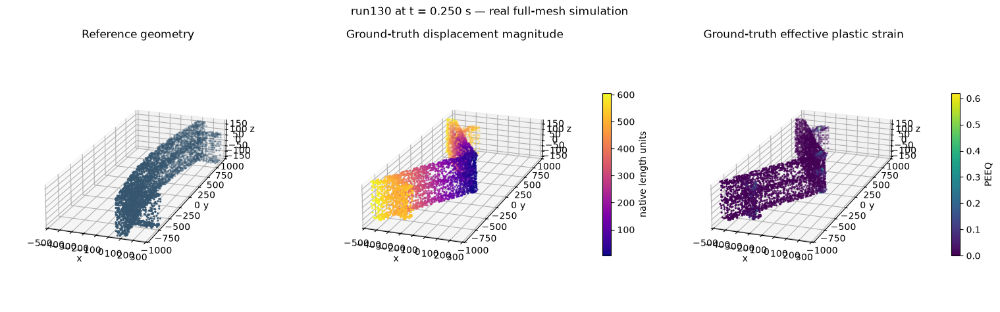

In [3]:
# A real high-speed/thin validation case, not a synthetic beam.
case_path = VALIDATION_DIR / "run130.vtp"
case = pv.read(case_path)
reference = np.asarray(case.points, dtype=np.float64)
final_displacement = np.asarray(case.point_data[displacement_names[-1]], dtype=np.float64)
final_position = reference + final_displacement
point_case = case.cell_data_to_point_data()
final_peeq = np.asarray(point_case.point_data[peeq_names[-1]], dtype=np.float64)
displacement_magnitude = np.linalg.norm(final_displacement, axis=1)

rng = np.random.default_rng(7)
show = np.sort(rng.choice(case.n_points, min(4000, case.n_points), replace=False))
bounds = np.vstack([reference, final_position])
lo, hi = bounds.min(0), bounds.max(0)
aspect = np.maximum(hi - lo, 1e-9)

fig = plt.figure(figsize=(16, 4.8))
panels = [
    (reference, np.zeros(case.n_points), "Reference geometry", "Greys", None),
    (final_position, displacement_magnitude, "Ground-truth displacement magnitude", "plasma", "native length units"),
    (final_position, final_peeq, "Ground-truth effective plastic strain", "viridis", "PEEQ"),
]
for column, (xyz, scalar, title, cmap, label) in enumerate(panels, 1):
    ax = fig.add_subplot(1, 3, column, projection="3d")
    if label is None:
        scatter = ax.scatter(*xyz[show].T, color="#36566f", s=1.8)
    else:
        scatter = ax.scatter(*xyz[show].T, c=scalar[show], s=1.8, cmap=cmap)
    ax.set(xlim=(lo[0], hi[0]), ylim=(lo[1], hi[1]), zlim=(lo[2], hi[2]),
           xlabel="x", ylabel="y", zlabel="z", title=title)
    ax.set_box_aspect(aspect)
    ax.view_init(elev=20, azim=-70)
    if label:
        fig.colorbar(scatter, ax=ax, shrink=0.62, label=label)
fig.suptitle("run130 at t = 0.250 s — real full-mesh simulation")
fig.tight_layout()
plt.show()


### What is available, and what was trained

| Quantity | Source representation | Notebook2 position demo | Five-channel extension |
|---|---|---:|---:|
| Absolute position | points + displacement | predicted | predicted |
| Effective plastic strain | cell scalar → point scalar | GT context only | one-shot / time-conditioned target |
| von-Mises stress | cell scalar → point scalar | GT context only | one-shot / time-conditioned target |
| Target shape | — | `[N,50,3]` | `[N,50,5]` |
| One-shot `out_dim` | — | `150` | `250` |
| Time-conditioned `out_dim` | — | `3` | `5` |

The unmodified autoregressive wrapper emits three position channels. Merely changing its
`out_dim` to five is not sufficient: its integration update is defined only for acceleration
in `x,y,z`. Consequently, the completed three-way comparison uses position only.


## 4. How the three temporal strategies work

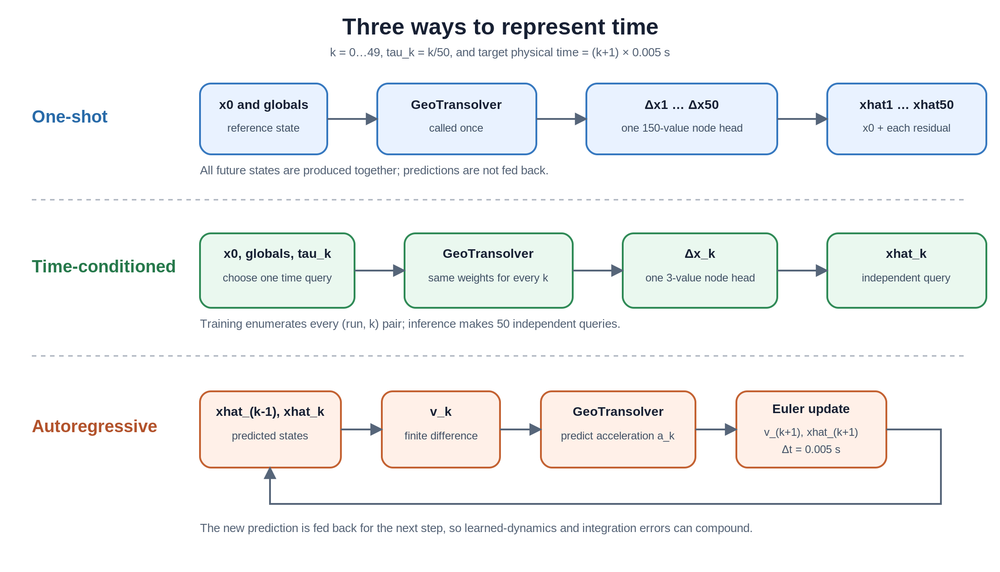

One-shot and time-conditioned are temporal prediction parameterizations. Only the autoregressive
wrapper performs an explicit numerical integration step. Its update is semi-implicit
Euler-shaped; this does not guarantee conservation or physical consistency.


In [4]:
# Short executable blueprints corresponding to rollout.py.
def decode_one_shot(raw, x0, steps=50):
    prediction = raw.reshape(x0.shape[0], steps, -1).clone()
    prediction[..., :3] += x0[:, None, :]       # residual -> absolute position
    return prediction

def time_query(k, steps=50, dt=0.005):
    return k / steps, (k + 1) * dt              # tau sent to model, physical target time

def semi_implicit_euler(x_now, velocity, acceleration, dt=0.005):
    velocity_next = velocity + dt * acceleration
    position_next = x_now + dt * velocity_next
    return position_next, velocity_next

mapping = pd.DataFrame(
    [(k, *time_query(k)) for k in (0, 24, 49)],
    columns=["target index k", "model time tau=k/50", "physical time (s)"],
)
display(mapping)


,target index k,model time tau=k/50,physical time (s)
0,0,0.00,0.005
1,24,0.48,0.125
2,49,0.98,0.250


| Method | Training sample type | Dataset item | Training target | Calls per trajectory | Prediction feedback |
|---|---|---|---|---|---|
| One-shot | `all_time_steps` | one simulation | complete future trajectory | one | no |
| Time-conditioned | `one_time_step` | one simulation–time pair | one queried state | one per requested time | no |
| Autoregressive | `all_time_steps` | one simulation | complete future trajectory | one per rollout step | yes |

Time-conditioned training expands each simulation into one dataset item for every target time.
The resolved configurations below provide the exact sample counts and dimensions for this run.

## 5. Notebook training configuration

The demonstration calls the recipe's production `train.py` entry point. Its small epoch count is
chosen for a visible classroom run; production experiments belong in the PhysicsNeMo crash recipe
with a scheduler, checkpoint policy, and compute allocation appropriate to the study.

In [5]:
DEMO_EPOCHS = 2
DEMO_LEARNING_RATE = 1.0e-4
DEMO_METHOD = "bumper_geotransolver_oneshot"

demo_configuration = pd.Series({
    "recipe entry point": "train.py",
    "experiment config": DEMO_METHOD,
    "target": "position only [N, 50, 3]",
    "training simulations": len(train_files),
    "validation simulations": len(validation_files),
    "mesh points": mesh.n_points,
    "epochs": DEMO_EPOCHS,
    "validation frequency": "every epoch",
    "checkpoint": "final demo epoch",
}, name="notebook demonstration")
display(demo_configuration.to_frame())

,notebook demonstration
recipe entry point,train.py
experiment config,bumper_geotransolver_oneshot
target,"position only [N, 50, 3]"
training simulations,129
validation simulations,5
mesh points,13675
epochs,2
validation frequency,every epoch
checkpoint,final demo epoch


## 6. Full-mesh two-epoch training run

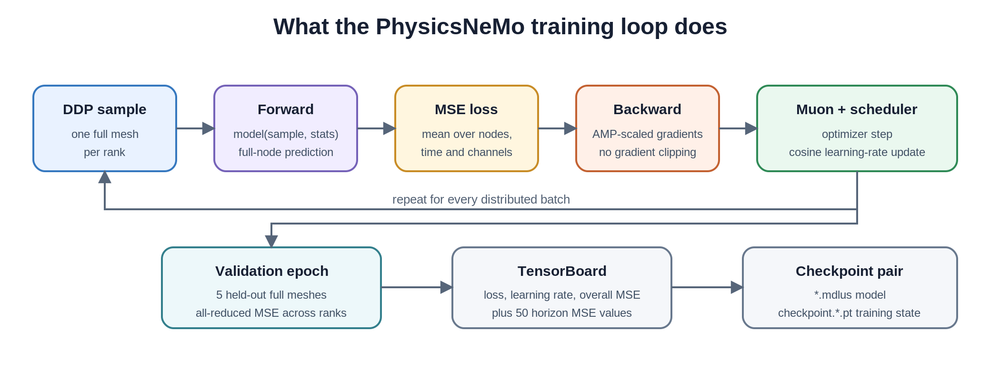

PhysicsNeMo's `train.py` wraps the forward/loss/backpropagation operation with distributed
sampling, AMP, Muon, validation reduction, TensorBoard logging, and paired checkpoints:


In [6]:
import torch.nn.functional as F

def one_training_step(model, sample, data_stats, optimizer, scaler):
    optimizer.zero_grad(set_to_none=True)
    with torch.autocast("cuda", enabled=True):
        prediction = model(sample=sample, data_stats=data_stats)
        loss = F.mse_loss(prediction, sample.node_target)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    return loss.detach()


### Isolated two-epoch one-shot run

This run uses all supplied training and validation simulations and every mesh point. A fresh
position-only one-shot model writes its normalization statistics, TensorBoard events, and final
checkpoint to `DEMO_RUN`.

Two epochs execute the complete training and validation path but do not produce a converged
accuracy result. Longer training, resumption, checkpoint selection, and multi-method studies are
run from the PhysicsNeMo crash recipe rather than from this notebook.

In [7]:
from collections import deque
import subprocess, time

ansi_escape = re.compile(r"\[[0-9;]*m")

def run_logged(command, cwd, log_path, keep_pattern, extra_env=None):
    environment = os.environ.copy()
    environment.update(OMP_NUM_THREADS="4", PYTHONUNBUFFERED="1")
    if extra_env:
        environment.update(extra_env)
    matcher, tail = re.compile(keep_pattern), deque(maxlen=60)
    with open(log_path, "w", encoding="utf-8") as raw_log:
        process = subprocess.Popen(
            command, cwd=cwd, env=environment, text=True,
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT, bufsize=1,
        )
        for line in process.stdout:
            raw_log.write(line)
            raw_log.flush()
            tail.append(line)
            if matcher.search(line):
                print(public_line(line), end="", flush=True)
        return_code = process.wait()
    if return_code:
        print("".join(tail))
        raise subprocess.CalledProcessError(return_code, command)

def public_line(line):
    return ansi_escape.sub("", line).replace(str(DEMO_RUN), "$NOTEBOOK2_DEMO_DIR")

def replay_selected(log_path, keep_pattern):
    matcher = re.compile(keep_pattern)
    for line in Path(log_path).read_text(encoding="utf-8").splitlines():
        if matcher.search(line):
            print(public_line(line))

run_live = os.environ.get("RUN_NOTEBOOK2_DEMO", "0") == "1"
nproc = min(8, torch.cuda.device_count())
if 1 < nproc < len(validation_files):
    nproc = 1
training_marker = DEMO_RUN / "TRAINING_COMPLETE"
training_log = DEMO_RUN / "training_stdout.log"
keep_training = (
    rf"Number of validation samples|Model parameters|Training started|"
    rf"Epoch \d+/{DEMO_EPOCHS} avg_loss|Validation epoch \d+:|"
    rf"Saved model|Training completed"
)
model_overrides = [
    f"--config-name={DEMO_METHOD}", "reader=vtp",
    "~model.activation_checkpointing", "~model.checkpointing_ratio",
    "~model.activation_checkpointing_components",
    f"training.raw_data_dir={TRAIN_DIR}",
    f"training.raw_data_dir_validation={VALIDATION_DIR}",
    f"training.global_features_filepath={DATA_ROOT / 'global_features.json'}",
    f"training.num_time_steps={len(times)}",
    f"training.num_training_samples={len(train_files)}",
    f"training.num_validation_samples={len(validation_files)}",
    "training.optimizer=muon", "training.num_dataloader_workers=0",
    f"training.start_lr={DEMO_LEARNING_RATE}", f"training.end_lr={DEMO_LEARNING_RATE}",
    f"training.epochs={DEMO_EPOCHS}", "training.validation_freq=1",
    f"training.save_checkpoint_freq={DEMO_EPOCHS}",
    "datapipe.dynamic_targets=[]", f"datapipe.stats_dir={DEMO_RUN / 'stats'}",
    f"training.ckpt_path={DEMO_RUN / 'checkpoints'}",
    f"training.tensorboard_log_dir={DEMO_RUN / 'tensorboard'}",
    "model.functional_dim=3", f"model.out_dim={(len(times) - 1) * 3}",
    "model.global_dim=3",
]

print(f"Training execution : {'run' if run_live else 'saved log'}")
print(f"GPUs / data / mesh : {nproc} / {len(train_files)} train + "
      f"{len(validation_files)} validation / {mesh.n_points:,} points")
print("Isolated output    : $NOTEBOOK2_DEMO_DIR")
if run_live:
    for name in ["checkpoints", "stats", "tensorboard", "train_hydra",
                 "inference_hydra", "predicted_vtps", "exact_vtps", "inference_input"]:
        (DEMO_RUN / name).mkdir(parents=True, exist_ok=True)
if run_live and not training_marker.exists():
    assert nproc > 0, "A CUDA device is required for the training demonstration."
    if any((DEMO_RUN / "checkpoints").iterdir()):
        raise RuntimeError("Partial demo checkpoint state exists; inspect it before retrying.")
    command = [sys.executable, "-m", "torch.distributed.run", "--standalone",
           f"--nproc_per_node={nproc}", "train.py"]
    command += model_overrides + [
        f"inference.raw_data_dir_test={VALIDATION_DIR}",
        f"hydra.run.dir={DEMO_RUN / 'train_hydra'}",
    ]
    run_logged(command, RECIPE_DIR, training_log, keep_training)
    training_marker.touch()
elif training_log.exists():
    print("Training log summary:")
    replay_selected(training_log, keep_training)
else:
    print(f"Training artifacts unavailable: {DEMO_RUN}")

model_file = DEMO_RUN / f"checkpoints/GeoTransolverOneShot.0.{DEMO_EPOCHS}.mdlus"
state_file = DEMO_RUN / f"checkpoints/checkpoint.0.{DEMO_EPOCHS}.pt"
if training_marker.exists():
    assert model_file.is_file() and state_file.is_file()
    print(f"Checkpoint pair    : {model_file.name} + {state_file.name}")

Training execution : saved log
GPUs / data / mesh : 8 / 129 train + 5 validation / 13,675 points
Isolated output    : $NOTEBOOK2_DEMO_DIR
Training log summary:
[2026-09-11 02:54:37,110][main][INFO] - Number of validation samples: 5
[2026-09-11 02:54:39,957][main][INFO] - Model parameters: 7,156,572
[2026-09-11 02:54:40,484][main][INFO] - Training started...
[2026-09-11 02:54:45,346][main][INFO] - Epoch 1/2 avg_loss: 1.020254 lr: 1.000e-04 duration: 4.86s
[2026-09-11 02:54:45,484][main][INFO] - Validation epoch 1: MSE: 0.863147
[2026-09-11 02:54:46,460][main][INFO] - Epoch 2/2 avg_loss: 0.707528 lr: 1.000e-04 duration: 0.92s
[2026-09-11 02:54:46,641][checkpoint][INFO] - Saved model state dictionary: $NOTEBOOK2_DEMO_DIR/checkpoints/GeoTransolverOneShot.0.2.mdlus
[2026-09-11 02:54:46,683][main][INFO] - Saved model on rank 0
[2026-09-11 02:54:46,696][main][INFO] - Validation epoch 2: MSE: 0.680140
[2026-09-11 02:54:46,745][main][INFO] - Training completed!
Checkpoint pair    : GeoTransolve

,epoch,rank-0 training loss,all-reduced validation MSE
0,1,1.020254,0.863147
1,2,0.707528,0.680140


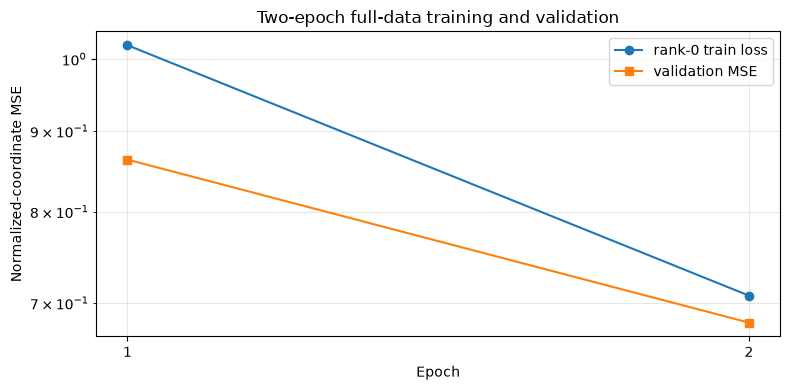

Training loss is rank 0's local mean; validation MSE is reduced across all five cases.


In [8]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

event_files = list((DEMO_RUN / "tensorboard").glob("events.out.tfevents.*"))
if event_files:
    accumulator = EventAccumulator(str(DEMO_RUN / "tensorboard"), size_guidance={"scalars": 0})
    accumulator.Reload()

    def scalar_series(tag):
        return {event.step + 1: float(event.value) for event in accumulator.Scalars(tag)}

    demo_loss = scalar_series("loss")
    demo_validation = scalar_series("val/MSE")
    demo_epochs = sorted(set(demo_loss) & set(demo_validation))
    demo_metrics = pd.DataFrame({
        "epoch": demo_epochs,
        "rank-0 training loss": [demo_loss[e] for e in demo_epochs],
        "all-reduced validation MSE": [demo_validation[e] for e in demo_epochs],
    })
    display(demo_metrics)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(demo_epochs, [demo_loss[e] for e in demo_epochs], "o-", label="rank-0 train loss")
    ax.semilogy(demo_epochs, [demo_validation[e] for e in demo_epochs], "s-", label="validation MSE")
    ax.set(xlabel="Epoch", ylabel="Normalized-coordinate MSE",
           title="Two-epoch full-data training and validation")
    ax.set_xticks(demo_epochs)
    ax.grid(alpha=0.3, which="both")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("Training loss is rank 0's local mean; validation MSE is reduced across all five cases.")
else:
    print("Run the two-epoch training cell to create TensorBoard metrics.")

## 7. Inference from the new epoch-2 checkpoint

This section closes the demonstration loop by loading the checkpoint and normalization statistics
created above. It exports 50 predicted and exact full-mesh frames for `validation/run1.vtp`, then
computes native-space position error. The result shows pipeline mechanics, not converged accuracy.

Inference execution : saved log
Demo checkpoint     : GeoTransolverOneShot.0.2.mdlus
Inference log summary:
[2026-09-11 02:55:01,461][checkpoint][INFO] - Loaded checkpoint file $NOTEBOOK2_DEMO_DIR/checkpoints/checkpoint.0.2.pt to device cuda:0
[2026-09-11 02:55:01,461][inference][INFO] - [Rank 0] Loaded checkpoint $NOTEBOOK2_DEMO_DIR/checkpoints
[2026-09-11 02:55:01,462][inference][INFO] - [Rank 0] Processing run: run1
[2026-09-11 02:55:08,388][inference][INFO] - [Rank 0] Finished run: run1
[2026-09-11 02:55:08,389][inference][INFO] - Inference completed successfully.


Exported frames    : 50 exact + 50 predicted
Trajectory RMSE    : 265.9232 native length units
Final-frame RMSE   : 203.6338 native length units


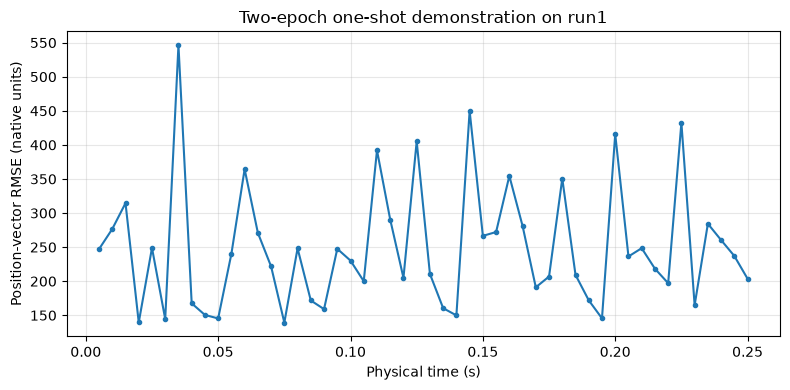

In [9]:
run_demo_inference = os.environ.get("RUN_NOTEBOOK2_DEMO", "0") == "1"
inference_marker = DEMO_RUN / "INFERENCE_COMPLETE"
inference_log = DEMO_RUN / "inference_stdout.log"
keep_inference = r"Loaded checkpoint|Processing run:|Finished run:|Inference completed"

print(f"Inference execution : {'run' if run_demo_inference else 'saved log'}")
print(f"Demo checkpoint     : {model_file.name}")
if run_demo_inference and not inference_marker.exists():
    assert model_file.is_file() and state_file.is_file(), "Run the training cell first."
    inference_input = DEMO_RUN / "inference_input"
    inference_input.mkdir(parents=True, exist_ok=True)
    input_link = inference_input / "run1.vtp"
    if input_link.is_symlink() or input_link.exists():
        input_link.unlink()
    input_link.symlink_to(VALIDATION_DIR / "run1.vtp")
    if any((DEMO_RUN / "predicted_vtps").rglob("*.vtp")):
        raise RuntimeError("Partial inference output exists; inspect it before retrying.")
    inference_command = [sys.executable, "inference.py"] + model_overrides + [
        f"inference.raw_data_dir_test={inference_input}",
        f"inference.output_dir_pred={DEMO_RUN / 'predicted_vtps'}",
        f"inference.output_dir_exact={DEMO_RUN / 'exact_vtps'}",
        f"hydra.run.dir={DEMO_RUN / 'inference_hydra'}",
    ]
    run_logged(inference_command, RECIPE_DIR, inference_log, keep_inference)
    inference_marker.touch()
elif inference_log.exists():
    print("Inference log summary:")
    replay_selected(inference_log, keep_inference)
else:
    print("Run the two-epoch training and inference cells to create prediction files.")

exact_demo_files = sorted((DEMO_RUN / "exact_vtps").glob("rank*/run1/frame_*_exact.vtp"))
predicted_demo_files = sorted(
    (DEMO_RUN / "predicted_vtps").glob("rank*/run1/frame_*_pred.vtp"))

if inference_marker.exists():
    assert len(exact_demo_files) == len(predicted_demo_files) == len(times) - 1, (
        "A completed inference run must contain exactly 50 exact and 50 predicted frames."
    )
    frame_rmse, squared_sum, vector_count = [], 0.0, 0
    for exact_path in exact_demo_files:
        difference = np.asarray(pv.read(exact_path).point_data["difference"], dtype=np.float64)
        frame_rmse.append(np.sqrt(np.mean(np.sum(difference**2, axis=1))))
        squared_sum += np.sum(difference**2)
        vector_count += len(difference)
    demo_trajectory_rmse = np.sqrt(squared_sum / vector_count)
    print(f"Exported frames    : {len(exact_demo_files)} exact + "
          f"{len(predicted_demo_files)} predicted")
    print(f"Trajectory RMSE    : {demo_trajectory_rmse:.4f} native length units")
    print(f"Final-frame RMSE   : {frame_rmse[-1]:.4f} native length units")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(times[1:], frame_rmse, marker="o", markersize=3)
    ax.set(xlabel="Physical time (s)", ylabel="Position-vector RMSE (native units)",
           title="Two-epoch one-shot demonstration on run1")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

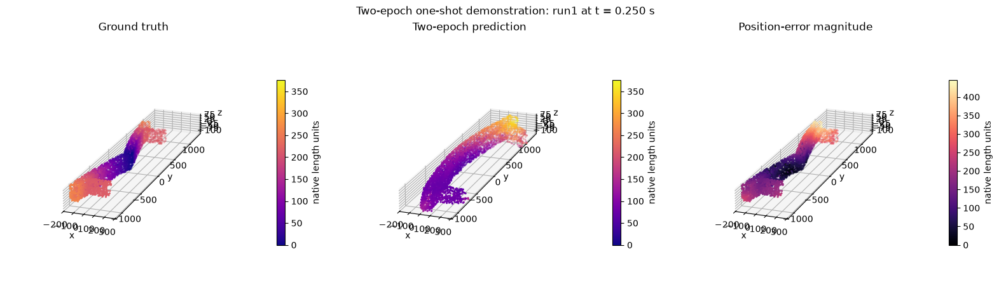

In [10]:
if exact_demo_files and predicted_demo_files:
    exact_path, predicted_path = exact_demo_files[-1], predicted_demo_files[-1]
    exact_mesh, predicted_mesh = pv.read(exact_path), pv.read(predicted_path)
    exact_position = np.asarray(exact_mesh.point_data["exact"], dtype=np.float64)
    predicted_position = np.asarray(predicted_mesh.point_data["prediction"], dtype=np.float64)
    reference_run1 = np.asarray(pv.read(VALIDATION_DIR / "run1.vtp").points, dtype=np.float64)
    position_error = np.linalg.norm(predicted_position - exact_position, axis=1)
    exact_umag = np.linalg.norm(exact_position - reference_run1, axis=1)
    predicted_umag = np.linalg.norm(predicted_position - reference_run1, axis=1)

    rng = np.random.default_rng(11)
    show = np.sort(rng.choice(len(exact_position), 3500, replace=False))
    all_xyz = np.vstack([exact_position, predicted_position])
    lo, hi = all_xyz.min(0), all_xyz.max(0)
    aspect = np.maximum(hi - lo, 1e-9)
    shared_displacement_max = max(exact_umag.max(), predicted_umag.max())

    fig = plt.figure(figsize=(16, 4.8))
    panels = [
        (exact_position, exact_umag, "Ground truth", shared_displacement_max, "plasma"),
        (predicted_position, predicted_umag, "Two-epoch prediction", shared_displacement_max, "plasma"),
        (exact_position, position_error, "Position-error magnitude", position_error.max(), "magma"),
    ]
    for column, (xyz, scalar, title, vmax, cmap) in enumerate(panels, 1):
        ax = fig.add_subplot(1, 3, column, projection="3d")
        scatter = ax.scatter(*xyz[show].T, c=scalar[show], s=1.8, cmap=cmap, vmin=0, vmax=vmax)
        ax.set(xlim=(lo[0], hi[0]), ylim=(lo[1], hi[1]), zlim=(lo[2], hi[2]),
               xlabel="x", ylabel="y", zlabel="z", title=title)
        ax.set_box_aspect(aspect)
        ax.view_init(elev=20, azim=-70)
        fig.colorbar(scatter, ax=ax, shrink=0.62, label="native length units")
    fig.suptitle("Two-epoch one-shot demonstration: run1 at t = 0.250 s")
    fig.tight_layout()
    plt.show()

## 8. Reference comparison from full recipe training

The remaining figures summarize separate full training runs performed with the PhysicsNeMo crash
recipe. They are embedded reference results; this notebook does not search Slurm job directories,
load those checkpoints, or reconstruct their metric tables.

Validation MSE is measured in normalized coordinate space. Export RMSE is the Euclidean
position-vector error in native length units.

### Reading the reference evidence

The convergence plot compares the complete training histories, the horizon plot shows how error
changes across the crash sequence, and the export-space plot aggregates all validation cases.
These results demonstrate the comparison workflow; reproducing them requires launching the
corresponding experiments from `train.py` and `inference.py` in the crash recipe.

### Convergence, horizon error, and export-space accuracy

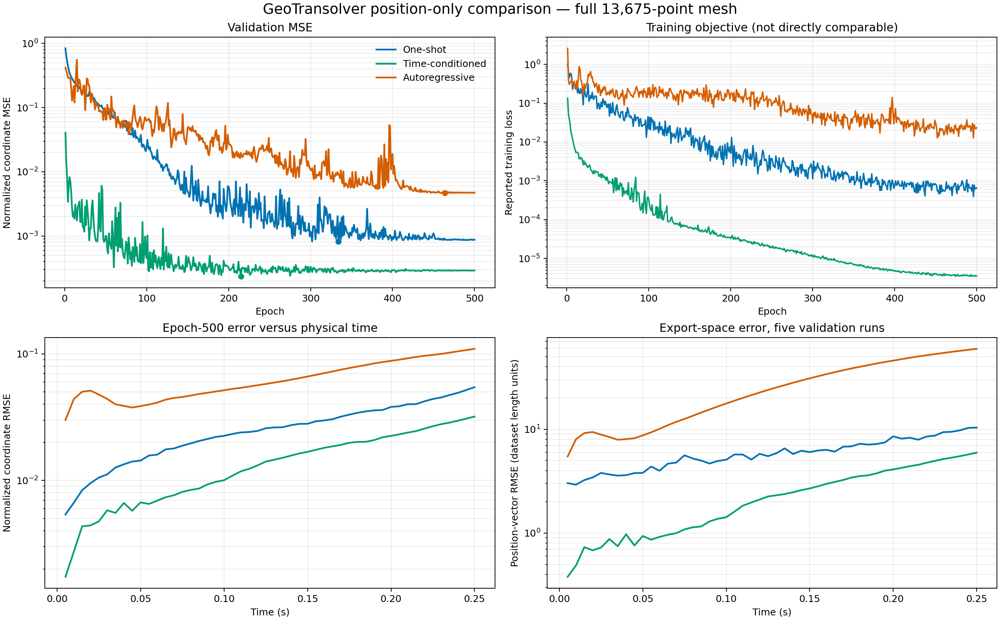

The time-conditioned model is most accurate here. Both direct methods still become less accurate
near the end of the crash; "no feedback" does not mean flat or bounded error. The autoregressive
recurrence adds a second mechanism: each imperfect prediction becomes the next input.


### Generalization across all five validation simulations

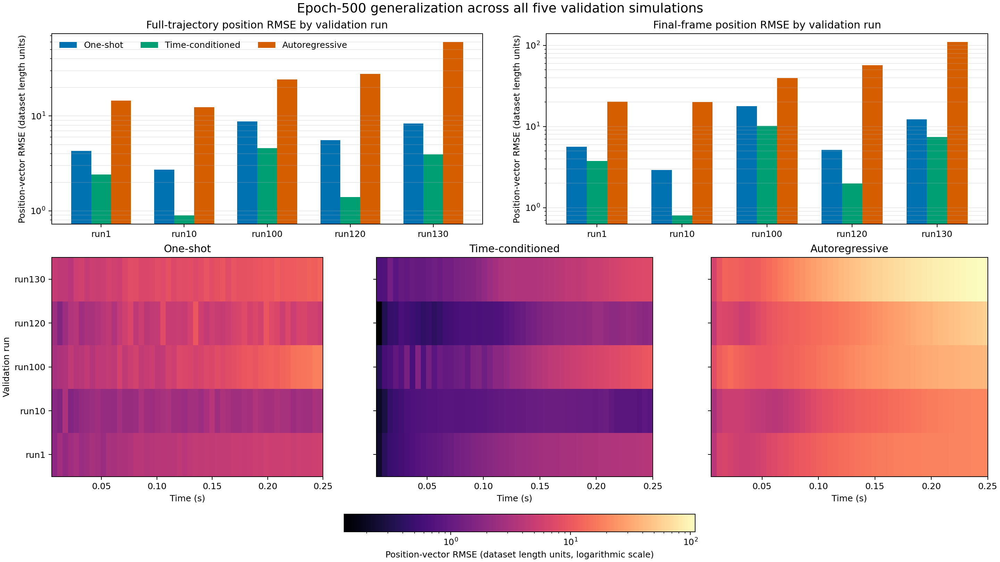

Time-conditioned wins every run and frame. `run130`—high speed and the thinnest section—is the
clearest autoregressive failure case, while `run1` is a useful representative case.


## 9. Full-mesh prediction animations

Each animation contains 50 target frames (`0.005 ... 0.250 s`) and all 13,675 mesh points. Fixed
cameras and shared color scales are applied across methods and frames.

**Representative validation case — run1**

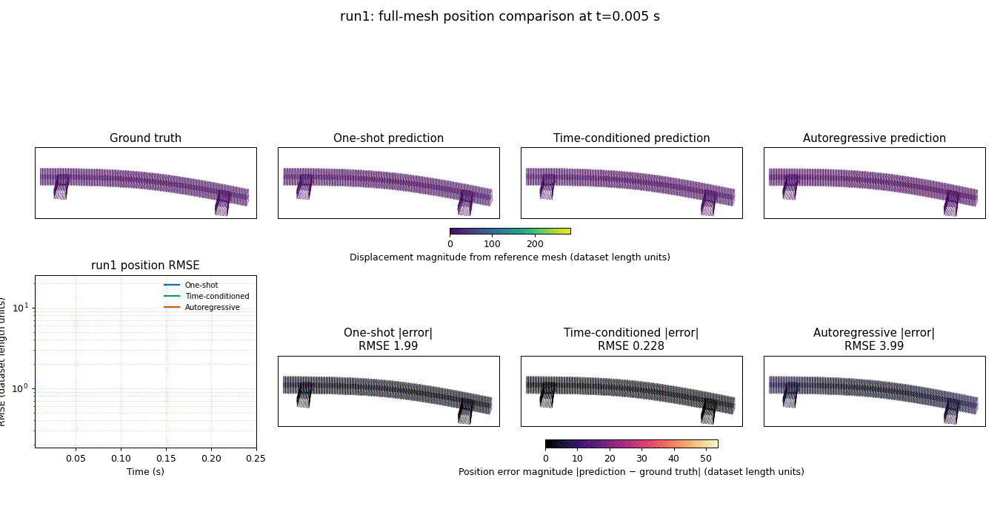

**Hard high-speed/thin case — run130**

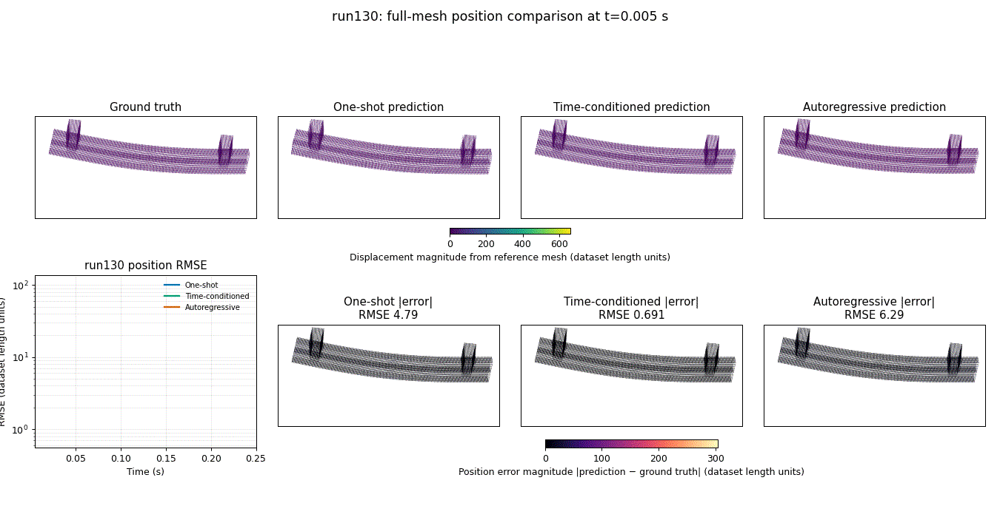


### Final-frame spatial comparison

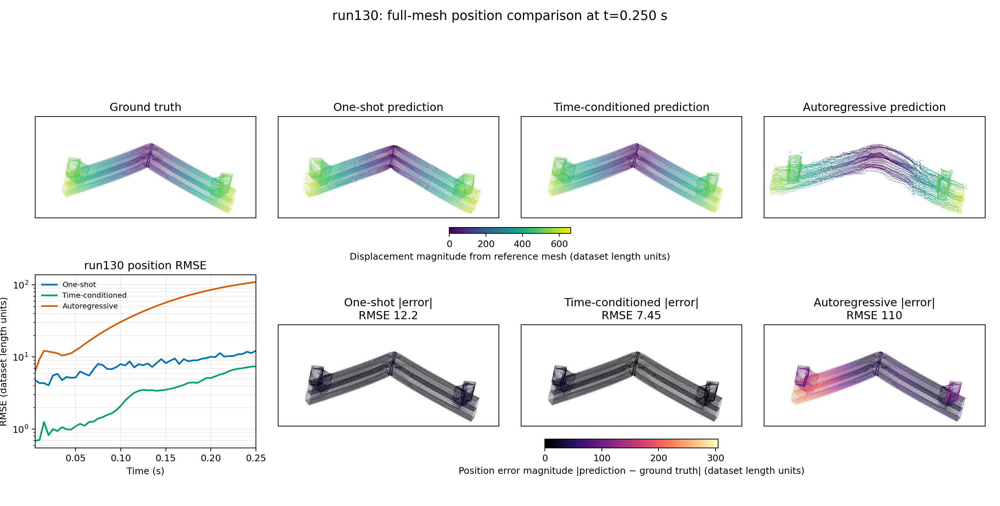

The shared spatial view exposes both local error structure and accumulated autoregressive drift
for the high-speed, thin-section validation case. The displayed values come directly from the
exported final-frame VTPs.

## 10. Where do the remaining position errors occur?

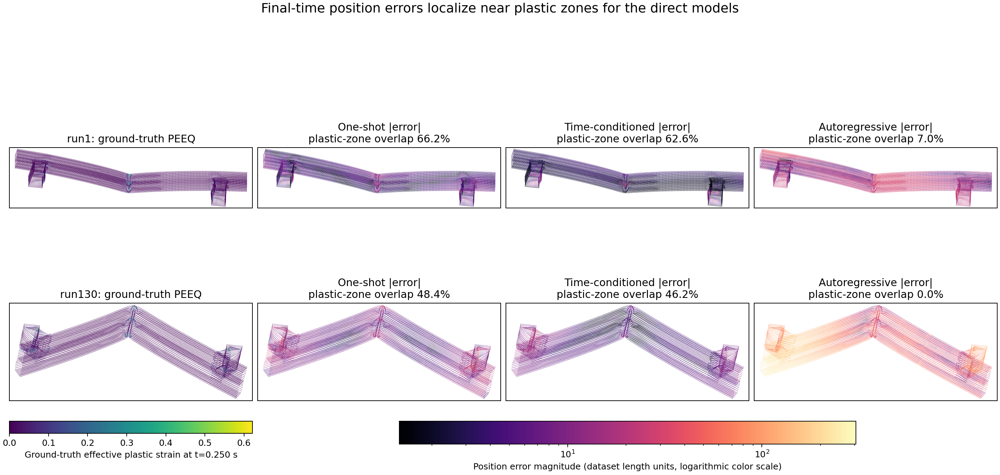

The top 5% of direct-model position errors overlap strongly with the top 10% ground-truth PEEQ
zone. The autoregressive error is instead dominated by global accumulated drift. **PEEQ in this
figure is ground truth only; these checkpoints do not predict it.**


The percentages printed in the figure compare the highest-error nodes with the ground-truth
plastic zone. A spatially random error set covering 5% of the mesh would place about 10% of those
nodes inside a region covering 10% of the mesh.

## 11. Conditioning space and simple OOD guardrails

OOD guardrails use the observed training-feature bounds. The plot shows the discrete design
space and labels the five validation points.


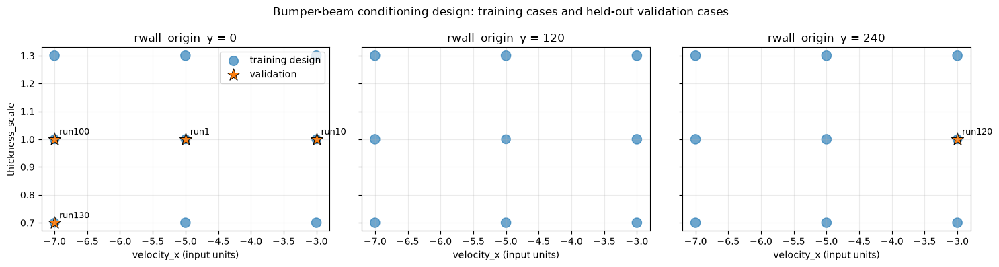

,training minimum,training maximum
velocity_x,-7.0,-3.0
thickness_scale,0.7,1.3
rwall_origin_y,0.0,240.0


In [11]:
train_ids = {p.stem.lower() for p in train_files}
validation_ids = {p.stem.lower() for p in validation_files}
conditioning_rows = []
for run_id, values in global_features.items():
    split = "train" if run_id in train_ids else "validation" if run_id in validation_ids else "unused"
    conditioning_rows.append({"run": run_id, "split": split, **values})
conditioning = pd.DataFrame(conditioning_rows)
conditioning = conditioning[conditioning.split.isin(["train", "validation"])]

wall_values = sorted(conditioning.rwall_origin_y.unique())
fig, axes = plt.subplots(1, len(wall_values), figsize=(15, 4), sharex=True, sharey=True)
for ax, wall_y in zip(axes, wall_values):
    panel = conditioning[conditioning.rwall_origin_y == wall_y]
    grouped = (panel[panel.split == "train"]
               .groupby(["velocity_x", "thickness_scale"]).size().reset_index(name="count"))
    ax.scatter(grouped.velocity_x, grouped.thickness_scale,
               s=35 + 14 * grouped["count"], alpha=0.65, label="training design")
    held_out = panel[panel.split == "validation"]
    ax.scatter(held_out.velocity_x, held_out.thickness_scale,
               marker="*", s=190, edgecolor="black", linewidth=0.7, label="validation")
    for row in held_out.itertuples():
        ax.annotate(row.run, (row.velocity_x, row.thickness_scale), xytext=(5, 5),
                    textcoords="offset points", fontsize=9)
    ax.set_title(f"rwall_origin_y = {wall_y:g}")
    ax.set_xlabel("velocity_x (input units)")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("thickness_scale")
axes[0].legend(loc="best")
fig.suptitle("Bumper-beam conditioning design: training cases and held-out validation cases")
fig.tight_layout()
plt.show()

bounds = feature_frame.agg(["min", "max"]).T
display(bounds.rename(columns={"min": "training minimum", "max": "training maximum"}))


## 12. Evidence-based method selection

| Need | Method | Evidence / caveat |
|---|---|---|
| Best position accuracy on this crash sequence | **Time-conditioned** | Lowest error across the recorded validation run-frames; one call per requested time |
| Fast single-call trajectory inference | **One-shot** | One backbone call; second-best accuracy here |
| Stateful acceleration recurrence | **Autoregressive experimental configuration** | Semi-implicit Euler-shaped update, but severe drift with the `initial_vel=0` setup |
| Stress and plastic-strain predictions | **Retrain one-shot or time-conditioned with five channels** | Set `dynamic_targets=[effective_plastic_strain,stress_vm]`; no such claim is made for these position checkpoints |

A fair computational comparison counts optimizer steps and model calls, not just epochs.
Time-conditioned training creates one `(run,k)` item for each requested time; the other two
methods create one trajectory item per simulation.

## 13. Evaluation assumptions and limitations

- **Notebook run:** the executable training and inference cells use a fresh two-epoch one-shot model.
- **Reference figures:** the three-method comparison comes from separate full recipe runs and is embedded for study.
- **Full mesh:** training, validation, and inference use all 13,675 points; only plotting may sample points.
- **Split:** 129 training and five validation simulations; there is no independent test split here.
- **Metric units:** TensorBoard validation MSE is normalized; VTP position RMSE is in native length units.
- **Distributed logging:** training loss is rank 0's local mean; validation MSE is all-reduced.
- **Exporter clock:** `frame_000` is the first target at `0.005 s`; `frame_049` is `0.250 s`.
  Use `prediction`, `exact`, and `difference`; the inherited `displacement` field is one template
  frame behind the exported geometry.
- **Autoregressive initialization:** the reference autoregressive run used `initial_vel=0.0`, not
  a calibrated per-run velocity vector; that mismatch can contribute to early trajectory error.

## 14. Conclusions and remaining experimental gaps

The two-epoch one-shot run demonstrates the complete executable path from VTP input through
training, validation, checkpointing, inference, and spatial error inspection. It is intentionally
short and should not be used to judge surrogate accuracy.

The embedded reference study shows how temporal strategies can be compared after full recipe
training. Longer runs, checkpoint resumption and selection, time-conditioned or autoregressive
experiments, five-channel position/PEEQ/stress targets, and independent test studies belong in
the PhysicsNeMo crash recipe.